In [1]:
import pandas as pd
import numpy as np
import re 
import os
import cudf
import cupy
from cuml.model_selection import train_test_split
from cuml.feature_extraction.text import TfidfVectorizer
from cuml.preprocessing import OneHotEncoder
from cupy.sparse import hstack

In [2]:
DATASET_FOLDER = '../dataset/'

# Load the datasets
train_df = pd.read_csv(DATASET_FOLDER + 'train.csv')
test_df = pd.read_csv(DATASET_FOLDER + 'test.csv')

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Training data shape: (75000, 4)
Test data shape: (75000, 3)


In [3]:
train_df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [4]:
IMAGE_TRAIN_FOLDER = '../images_train/' 
train_df['filename'] = train_df['image_link'].str.split('/').str[-1]
train_df.head()

,sample_id,catalog_content,image_link,price,filename
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,51mo8htwTHL.jpg
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,71YtriIHAAL.jpg
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,51+PFEe-w-L.jpg
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,41mu0HAToDL.jpg
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,41sA037+QvL.jpg


In [5]:
train_df['image_path'] = IMAGE_TRAIN_FOLDER + train_df['filename']

In [6]:
IMAGE_TEST_FOLDER = '../images_test/' 
test_df['filename'] = test_df['image_link'].str.split('/').str[-1]
test_df['image_path'] = IMAGE_TEST_FOLDER + test_df['filename']

In [7]:
test_df.head()

,sample_id,catalog_content,image_link,filename,image_path
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...,71hoAn78AWL.jpg,../images_test/71hoAn78AWL.jpg
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...,61ex8NHCIjL.jpg,../images_test/61ex8NHCIjL.jpg
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...,61KCM61J8eL.jpg,../images_test/61KCM61J8eL.jpg
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...,51Ex6uOH7yL.jpg,../images_test/51Ex6uOH7yL.jpg
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...,71QYlrOMoSL.jpg,../images_test/71QYlrOMoSL.jpg


In [8]:
def parse_catalog_content(text):
    """
    Parses the structured text from catalog_content into separate features.
    """
    # Use a dictionary to store our extracted features
    features = {
        'item_name': '',
        'bullet_points': '',
        'value': np.nan, # Use NaN (Not a Number) for missing numerical values
        'unit': 'unknown'
    }

    # Ensure the input is a string
    text = str(text)

    # --- Extract Item Name ---
    # Look for "Item Name:" followed by any characters until the next "Bullet Point"
    match = re.search(r'Item Name:(.*?)(Bullet Point|$)', text, re.DOTALL)
    if match:
        features['item_name'] = match.group(1).strip()

    # --- Extract all Bullet Points and combine them ---
    # Find all occurrences of "Bullet Point X:"
    bullets = re.findall(r'Bullet Point \d+:(.*?)(Bullet Point|Value|$)', text, re.DOTALL)
    # Join all found bullet points into a single string
    features['bullet_points'] = ' '.join([b[0].strip() for b in bullets])

    # --- Extract Value ---
    match = re.search(r'Value:\s*([\d\.]+)', text)
    if match:
        try:
            # Convert the extracted string to a float
            features['value'] = float(match.group(1))
        except ValueError:
            # If conversion fails, leave it as NaN
            pass 

    # --- Extract Unit ---
    match = re.search(r'Unit:\s*(\w+)', text)
    if match:
        features['unit'] = match.group(1).strip()
        
    return features
def extract_ipq(text):
    """
    Extracts the Item Pack Quantity (IPQ) from a product description string.
    """
    text = str(text).lower()
    patterns = [
        r'pack of (\d+)', r'(\d+)\s*-?\s*pack', r'(\d+)\s*count',
        r'(\d+)\s*ct', r'ipq\s*:\s*(\d+)', r'case of (\d+)'
    ]
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))
    return 1 # Default to 1 if no pack size is found

In [9]:
parsed_features_train = train_df['catalog_content'].apply(parse_catalog_content).apply(pd.Series)

parsed_features_test = test_df['catalog_content'].apply(parse_catalog_content).apply(pd.Series)
train_df = pd.concat([train_df, parsed_features_train], axis=1)
test_df = pd.concat([test_df, parsed_features_test], axis=1)

In [10]:
train_df['ipq'] = train_df['catalog_content'].apply(extract_ipq)
test_df['ipq'] = test_df['catalog_content'].apply(extract_ipq)

In [11]:
train_df[['item_name', 'bullet_points', 'value', 'unit', 'ipq']].head()

,item_name,bullet_points,value,unit,ipq
0,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",,72.00,Fl,6
1,"Salerno Cookies, The Original Butter Cookies, ...",Original Butter Cookies: Classic butter cookie...,32.00,Ounce,4
2,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Loaded with hearty long grain wild rice and ve...,11.40,Ounce,6
3,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,"Add to your favorite appetizers, dips & spread...",11.25,Ounce,1
4,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",,12.00,Count,1


In [12]:
train_df['clean_text'] = train_df['item_name'] + ' ' + train_df['bullet_points']
test_df['clean_text'] = test_df['item_name'] + ' ' + test_df['bullet_points']
train_df[['catalog_content', 'clean_text']].head()

,catalog_content,clean_text
0,"Item Name: La Victoria Green Taco Sauce Mild, ...","La Victoria Green Taco Sauce Mild, 12 Ounce (P..."
1,"Item Name: Salerno Cookies, The Original Butte...","Salerno Cookies, The Original Butter Cookies, ..."
2,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...","Bear Creek Hearty Soup Bowl, Creamy Chicken wi..."
3,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...
4,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per..."


In [13]:
train_df_cleaned = train_df.drop(columns=['catalog_content', 'filename', 'item_name', 'bullet_points','image_link'])
test_df_cleaned = test_df.drop(columns=['catalog_content', 'filename', 'item_name', 'bullet_points','image_link'])

In [14]:
train_df_cleaned.head()

,sample_id,price,image_path,value,unit,ipq,clean_text
0,33127,4.89,../images_train/51mo8htwTHL.jpg,72.00,Fl,6,"La Victoria Green Taco Sauce Mild, 12 Ounce (P..."
1,198967,13.12,../images_train/71YtriIHAAL.jpg,32.00,Ounce,4,"Salerno Cookies, The Original Butter Cookies, ..."
2,261251,1.97,../images_train/51+PFEe-w-L.jpg,11.40,Ounce,6,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi..."
3,55858,30.34,../images_train/41mu0HAToDL.jpg,11.25,Ounce,1,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...
4,292686,66.49,../images_train/41sA037+QvL.jpg,12.00,Count,1,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per..."


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'log_price'}>]], dtype=object)

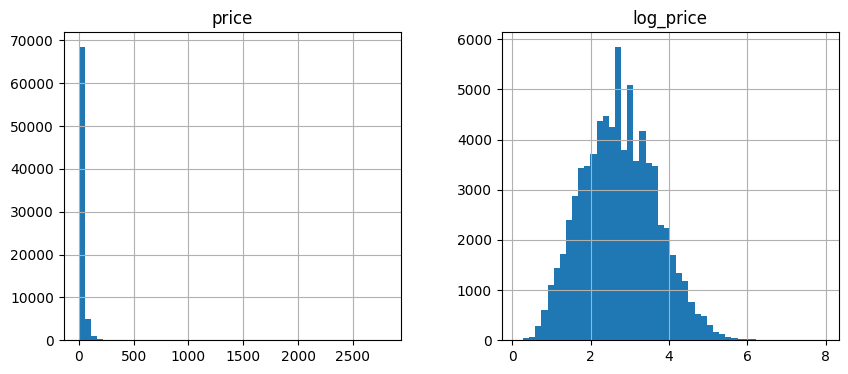

In [15]:
train_df_cleaned['log_price'] = np.log1p(train_df_cleaned['price'])
train_df_cleaned[['price', 'log_price']].hist(bins=50, figsize=(10, 4))

In [16]:
train_df_cleaned.isnull().sum()

sample_id       0
price           0
image_path      0
value         940
unit            0
ipq             0
clean_text      0
log_price       0
dtype: int64

In [17]:
median_value = train_df_cleaned['value'].median()
median_value_test=test_df_cleaned['value'].median()
# Fill missing values in both train and test sets with this median
train_df_cleaned['value'].fillna(median_value, inplace=True)
test_df_cleaned['value'].fillna(median_value, inplace=True)

In [18]:
train_df_cleaned.isnull().sum()

sample_id     0
price         0
image_path    0
value         0
unit          0
ipq           0
clean_text    0
log_price     0
dtype: int64

In [19]:
n_samples = 75000
train_sample_df = train_df_cleaned.sample(n=n_samples, random_state=42)

# Convert the pandas DataFrame sample to a cuDF (GPU) DataFrame
train_gdf = cudf.from_pandas(train_sample_df)
test_gdf = cudf.from_pandas(test_df_cleaned)

In [20]:
train_df_cleaned.head()

,sample_id,price,image_path,value,unit,ipq,clean_text,log_price
0,33127,4.89,../images_train/51mo8htwTHL.jpg,72.00,Fl,6,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",1.773256
1,198967,13.12,../images_train/71YtriIHAAL.jpg,32.00,Ounce,4,"Salerno Cookies, The Original Butter Cookies, ...",2.647592
2,261251,1.97,../images_train/51+PFEe-w-L.jpg,11.40,Ounce,6,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",1.088562
3,55858,30.34,../images_train/41mu0HAToDL.jpg,11.25,Ounce,1,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,3.444895
4,292686,66.49,../images_train/41sA037+QvL.jpg,12.00,Count,1,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",4.211979


In [21]:
# --- THE CORRECT SPLITTING METHOD ---
# 1. Create an array of row numbers (indices)
indices = cupy.arange(train_gdf.shape[0])

# 2. Split the indices
train_indices, val_indices = train_test_split(indices, test_size=0.2, random_state=42)

# 3. Use the indices to create your new DataFrames
train_gdf_split = train_gdf.iloc[train_indices]
val_gdf = train_gdf.iloc[val_indices]
# --- END OF SPLITTING METHOD ---


print("Splitting complete!")
print(f"Training set size: {len(train_gdf_split)}")
print(f"Validation set size: {len(val_gdf)}")

Splitting complete!
Training set size: 60000
Validation set size: 15000


In [22]:
# --- Step 2: Feature Engineering (TF-IDF and One-Hot Encoding) ---
# We will learn the features ONLY from the training split.

# A) Text Features (TF-IDF)
print("\nCreating text features with TF-IDF...")
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
# Fit on the training split, then transform both train and validation
train_text_features = tfidf.fit_transform(train_gdf_split['clean_text'])
val_text_features = tfidf.transform(val_gdf['clean_text'])


Creating text features with TF-IDF...


In [23]:
# B) Categorical Features (One-Hot Encoding)
print("Creating categorical features with One-Hot Encoder...")
ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)
# Fit on the training split, then transform both train and validation
train_unit_features = ohe.fit_transform(train_gdf_split[['unit']])
val_unit_features = ohe.transform(val_gdf[['unit']])

Creating categorical features with One-Hot Encoder...


In [24]:
from cupyx.scipy.sparse import hstack, csr_matrix

# --- Step 3: Combine All Features into Final Matrices ---
print("\nCombining all features into final matrices...")

# A) Isolate and convert numerical features to sparse format
numerical_cols = ['value', 'ipq']
train_numerical_features = csr_matrix(train_gdf_split[numerical_cols].values)
val_numerical_features = csr_matrix(val_gdf[numerical_cols].values)

# B) Stack all sparse feature types horizontally
X_train = hstack([train_text_features, train_numerical_features, train_unit_features], format='csr')
X_val = hstack([val_text_features, val_numerical_features, val_unit_features], format='csr')

# C) Prepare the target variables (y) for both sets
y_train = train_gdf_split['log_price'].values
y_val = val_gdf['log_price'].values

print("Final training feature matrix shape:", X_train.shape)
print("Final validation feature matrix shape:", X_val.shape)


Combining all features into final matrices...
Final training feature matrix shape: (60000, 10083)
Final validation feature matrix shape: (15000, 10083)


In [25]:
X_train

In [59]:
!pip install xgboost

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
You should consider upgrading via the '/usr/bin/python -m pip install --upgrade pip' command.


In [26]:
from cupyx.scipy.sparse import hstack, csr_matrix
import cupy
import xgboost as xgb
import numpy as np

# --- Step 1: Combine All Features into a SPARSE Matrix (as before) ---
# (Assuming train_text_features, train_numerical_features, etc. are already created)
print("Combining features into a sparse matrix...")

X_train_sparse = hstack([train_text_features, train_numerical_features, train_unit_features], format='csr')
X_val_sparse = hstack([val_text_features, val_numerical_features, val_unit_features], format='csr')

# --- Step 2: Convert the Sparse Matrix to a DENSE CuPy Array ---
# THIS IS THE FIX. .toarray() converts the format.
print("Converting sparse matrix to dense CuPy array for XGBoost...")
X_train = X_train_sparse.toarray()
X_val = X_val_sparse.toarray()


# --- Step 3: Train XGBoost (This will now work perfectly) ---
print("Training the XGBoost model on the GPU...")

model = xgb.XGBRegressor(
    tree_method='gpu_hist',
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=100,
    random_state=42
)

# The model is now receiving a dense CuPy array, which it supports.
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

print("✅ Model training complete!")


Combining features into a sparse matrix...
Converting sparse matrix to dense CuPy array for XGBoost...
Training the XGBoost model on the GPU...
[0]	validation_0-rmse:1.80416
[1]	validation_0-rmse:1.39543
[2]	validation_0-rmse:1.13800
[3]	validation_0-rmse:0.98597
[4]	validation_0-rmse:0.89957
[5]	validation_0-rmse:0.85128
[6]	validation_0-rmse:0.82415
[7]	validation_0-rmse:0.80880
[8]	validation_0-rmse:0.79759
[9]	validation_0-rmse:0.79090
[10]	validation_0-rmse:0.78544
[11]	validation_0-rmse:0.78143
[12]	validation_0-rmse:0.77812
[13]	validation_0-rmse:0.77536
[14]	validation_0-rmse:0.77345
[15]	validation_0-rmse:0.76792
[16]	validation_0-rmse:0.76600
[17]	validation_0-rmse:0.76411
[18]	validation_0-rmse:0.76281
[19]	validation_0-rmse:0.76116
[20]	validation_0-rmse:0.75944
[21]	validation_0-rmse:0.75786
[22]	validation_0-rmse:0.75628
[23]	validation_0-rmse:0.75506
[24]	validation_0-rmse:0.75301
[25]	validation_0-rmse:0.75196
[26]	validation_0-rmse:0.75092
[27]	validation_0-rmse:0.7504

In [27]:
# --- Evaluate Your Model ---

def smape(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    epsilon = 1e-8
    ratio = numerator / (denominator + epsilon)
    return np.mean(ratio) * 100

# Make predictions on the validation set
log_preds_val = model.predict(X_val)

# Convert predictions and true labels back to the original price scale
val_predictions = np.expm1(cupy.asnumpy(log_preds_val))
val_true_prices = np.expm1(cupy.asnumpy(y_val))

# Calculate the SMAPE score
validation_score = smape(val_true_prices, val_predictions)

print(f"\nYour SMAPE score on the validation set is: {validation_score:.4f}%")


Your SMAPE score on the validation set is: 55.5995%


# Test Prediction

In [28]:
test_gdf

,sample_id,image_path,value,unit,ipq,clean_text
0,100179,../images_test/71hoAn78AWL.jpg,10.5,Ounce,1,Rani 14-Spice Eshamaya's Mango Chutney (Indian...
1,245611,../images_test/61ex8NHCIjL.jpg,2.0,Fl,1,Natural MILK TEA Flavoring extract by HALO PAN...
2,146263,../images_test/61KCM61J8eL.jpg,32.0,Ounce,1,Honey Filled Hard Candy - Bulk Pack 2 Pounds -...
3,95658,../images_test/51Ex6uOH7yL.jpg,2.0,Count,2,Vlasic Snack'mm's Kosher Dill 16 Oz (Pack of 2...
4,36806,../images_test/71QYlrOMoSL.jpg,32.0,Fl,1,"McCormick Culinary Vanilla Extract, 32 fl oz -..."
...,...,...,...,...,...,...
74995,93616,../images_test/51e9H27lgvL.jpg,2.4,Ounce,4,Good Seasons Zezty Italian Salad Dressing Mix ...
74996,249434,../images_test/61IpkExmVtL.jpg,7.0,Ounce,1,"Colombina Swirled Love Tiger Pops, Strawberry ..."
74997,162217,../images_test/A1NMggyCLzL.jpg,11.5,Fl,1,"Kerns, Guava Nectar, 11.5 Fl Oz Can"
74998,230487,../images_test/81P69kEP5qL.jpg,16.0,Ounce,1,NY SPICE SHOP Licorice Candy - 1 Pound Red Lic...


In [29]:
# A) Text Features (TF-IDF)
# Fit on the training split, then transform both train and validation
test_text_features = tfidf.transform(test_gdf['clean_text'])

In [30]:
# B) Categorical Features (One-Hot Encoding)
# Fit on the training split, then transform both train and validation
test_unit_features = ohe.transform(test_gdf[['unit']])

In [31]:
# --- Step 3: Combine All Features into Final Matrices ---
print("\nCombining all features into final matrices...")

# A) Isolate and convert numerical features to sparse format
numerical_cols = ['value', 'ipq']
test_numerical_features = csr_matrix(test_gdf[numerical_cols].values)

# B) Stack all sparse feature types horizontally
X_test = hstack([test_text_features, test_numerical_features, test_unit_features], format='csr')


Combining all features into final matrices...


In [33]:
X_test_pred = X_test.toarray()
price_log_preds_test = model.predict(X_test_pred)

In [34]:
test_df_original = pd.read_csv(DATASET_FOLDER + 'test.csv')

# --- Step 2: Inverse Transform Your Predictions ---
# Your model predicted the log of the price. We need to convert it back.
# np.expm1() is the inverse of np.log1p().
# We also move the predictions from the GPU (cupy) to the CPU (numpy).
print("Converting log predictions back to the original price scale...")
final_predictions = np.expm1(cupy.asnumpy(price_log_preds_test))

# --- Step 3: Create the Submission DataFrame ---
# The format must be exactly: 'sample_id', 'price'
print("Creating the submission DataFrame...")
submission_df = pd.DataFrame({
    'sample_id': test_df_original['sample_id'],
    'price': final_predictions
})

# --- Step 4: Safety Check ---
# Ensure there are no negative price predictions.
submission_df['price'] = submission_df['price'].clip(lower=0)

# --- Step 5: Save to CSV ---
# This creates the file you will upload to the competition.
# index=False is crucial to avoid an extra column in your file.
submission_filename = 'submissionxgb.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\n✅ Submission file '{submission_filename}' created successfully!")
print(submission_df.head())

Converting log predictions back to the original price scale...
Creating the submission DataFrame...

✅ Submission file 'submissionxgb.csv' created successfully!
   sample_id      price
0     100179  11.705326
1     245611  14.052822
2     146263  24.075701
3      95658  10.851784
4      36806  20.918552


In [35]:
test_df_original.head()

,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...
